# Experimento 13 — Modelo de dos niveles entrenado sin etiquetas ruidosas + diagnóstico de sobreajuste

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento9.ipynb` (modelo de dos niveles con corrección de tipeo, mejor score público) y
`experimento12.ipynb` (modelo de un nivel entrenado sin las reseñas de etiqueta casi aleatoria). La sección 1 repite
de forma resumida la configuración común (misma semilla, mismo split). Los experimentos anteriores **no se vuelven a
ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks. La única excepción es la
configuración del experimento 9, que se vuelve a medir aquí como **referencia** con las mismas 15 particiones que las
variantes nuevas (así la comparación es pareada).

**Contenido**
1. Configuración común (resumen)
2. Experimento 13 — Dos niveles sin etiquetas ruidosas

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy import stats
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_val_score, cross_val_predict)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta). Para comparar variantes se usa **CV
repetida de 3 × 5 = 15 particiones** sobre el 80 % (como en el experimento 12): las diferencias que se buscan son de
décimas y con 5 folds quedan dentro del ruido. Todas las variantes, incluida la referencia del experimento 9, se
evalúan con **las mismas 15 particiones**. Se decide con accuracy (métrica de Kaggle).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
PARTICIONES = list(cv_repetida.split(X_train, y_train))
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 7, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1)",
     "acc_cv": 0.9071, "std_cv": 0.0091, "acc_test": 0.9046, "envio": "submission_07.csv", "kaggle_publico": 0.91},
    {"experimento": 8, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",
     "acc_cv": 0.9048, "std_cv": 0.0083, "acc_test": 0.9096, "envio": "submission_08.csv", "kaggle_publico": None},
    {"experimento": 9, "descripcion": "Dos niveles con corrección de tipeo, SVM RBF (C=1)",
     "acc_train": 0.9358, "acc_cv": 0.9065, "std_cv": 0.0086, "acc_test": 0.9029, "envio": "submission_09.csv",
     "kaggle_publico": 0.91555},
    {"experimento": 12, "descripcion": "Un nivel: exp. 11 sin reseñas ruidosas al entrenar, LinearSVC (C=0,5); CV 3 × 5",
     "acc_train": 0.9188, "acc_cv": 0.9033, "std_cv": 0.0070, "acc_test": 0.8958, "envio": "submission_12.csv",
     "kaggle_publico": None},
]:
    resultados.append(fila)

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 8", "escenario": "Original", "accuracy": 0.9096},
    {"modelo": "Exp. 8", "escenario": "Oraciones desordenadas", "accuracy": 0.7621},
    {"modelo": "Exp. 8", "escenario": "Última oración al inicio", "accuracy": 0.6467},
    {"modelo": "Exp. 9", "escenario": "Original", "accuracy": 0.9029},
    {"modelo": "Exp. 9", "escenario": "Oraciones desordenadas", "accuracy": 0.7500},
    {"modelo": "Exp. 9", "escenario": "Última oración al inicio", "accuracy": 0.6021},
    {"modelo": "Exp. 12", "escenario": "Original", "accuracy": 0.8958},
    {"modelo": "Exp. 12", "escenario": "Oraciones desordenadas", "accuracy": 0.7317},
    {"modelo": "Exp. 12", "escenario": "Última oración al inicio", "accuracy": 0.5725},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91000
2,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN
3,9,"Dos niveles con corrección de tipeo, SVM RBF (C=1)",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
4,12,"Un nivel: exp. 11 sin reseñas ruidosas al entrenar, LinearSVC (C=0,5); CV 3 × 5",NaN,0.9188,0.9033,0.0070,NaN,0.8958,NaN,submission_12.csv,NaN


## 2. Experimento 13 — Dos niveles sin etiquetas ruidosas

**Motivación:** dos resultados anteriores apuntan a la misma idea.
- El experimento 12 mostró que ≈ 11 % de las reseñas (`negativo`/`positivo` que terminan en una frase evasiva) tiene
  una etiqueta prácticamente aleatoria, que el modelo solo puede **memorizar**. Sacarlas del entrenamiento no costó
  nada en validación. Pero se probó en el modelo de **un nivel** (CV ≈ 0,903), no en el de **dos niveles**, que es el
  mejor del proyecto (CV ≈ 0,907, Kaggle 0,91555).
- En el modelo de dos niveles, el **modelo de polaridad de oraciones** se entrena con la última opinión de *todas* las
  reseñas `negativo`/`positivo`, etiquetada con la clase de la reseña. En las reseñas ruidosas esa etiqueta es una
  moneda al aire: ≈ 16 % de sus ejemplos tiene una etiqueta aleatoria.

Además, en el grupo se planteó la duda de si los modelos con mejor score en Kaggle están **sobreajustados**
(memorizando datos). Este experimento la responde con mediciones, no con la brecha bruta entre entrenamiento y
validación, que mezcla dos cosas distintas (ver 2.4).

**Hipótesis:**
1. Entrenar el nivel 1 (sobre todo el modelo de polaridad) sin las reseñas ruidosas mejora la accuracy de validación
   del modelo de dos niveles, o al menos no la empeora y reduce la memorización.
2. Una parte importante de la brecha entre entrenamiento y validación es memorización de etiquetas aleatorias, no
   pérdida de capacidad predictiva en datos nuevos.

**Qué no cambia:** la evaluación siempre se hace con **todas** las reseñas (eval también contiene reseñas ruidosas).
El filtro solo afecta a los datos con los que se entrena, dentro de `fit`.

**Proceso:**
1. Definir los grupos de reseñas ruidosas (2.2).
2. Nivel 1 con filtro configurable y caché de features con cross-fitting para las 15 particiones (2.3).
3. Diagnóstico del sobreajuste por grupos con la configuración del experimento 9 (2.4).
4. Ablación: dónde aplicar el filtro (polaridad / nivel 1 completo / nivel 2) y qué grupos excluir, con prueba
   estadística pareada (2.5).
5. Ajuste del combinador (2.6), modelo final, test, robustez (2.7–2.8).
6. Curva de aprendizaje (2.9), registro y envío (2.10).

### 2.1 Definiciones

Las mismas funciones, el transformador `PartesE5` (`experimento5.ipynb`) y el `CorrectorTipeo` (`experimento9.ipynb`).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


y_np = y_train.to_numpy()

In [7]:
from collections import Counter

LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    """Todas las cadenas a distancia de edición 1: borrado, transposición, sustitución e inserción."""
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):
    """Reemplaza palabras raras por la palabra frecuente más parecida (distancia de edición 1)."""

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(candidatas, key=self.frecuentes_.get)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:   # palabra nunca vista en train
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(candidatas, key=self.frecuentes_.get)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]

### 2.2 Grupos de reseñas ruidosas

Se definen dos grupos, solo entre reseñas `negativo`/`positivo` (para saber si una reseña es ruidosa hace falta su
etiqueta, por eso el filtro **solo puede aplicarse a datos de entrenamiento**):

| Grupo | Definición | Evidencia previa |
|---|---|---|
| `evasiva` | la última oración es una frase evasiva (lista del experimento 4) | exp. 4 y 12: ninguna parte del texto predice la etiqueta mejor que el azar |
| `secundaria` | la última oración no evasiva empieza con un conector secundario (`de paso`, `por cierto`, `por otro lado`, `ademas`) | exp. 5: si contradice a la anterior, la etiqueta sigue a cualquiera de las dos ≈ 50 % |

El grupo `secundaria` es una aproximación simple de la del experimento 5 (no exige que contradiga a la opinión
anterior, porque eso requeriría un modelo de polaridad). Antes de usarlo como filtro, en 2.4 se verifica si de verdad
es impredecible.

In [8]:
NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def grupo_ruido(texto):
    """'evasiva', 'secundaria' o '' según cómo termina la reseña (no usa la etiqueta)."""
    if es_evasiva(dividir_oraciones(texto)[-1]):
        return "evasiva"
    if re.match(GRUPOS["secundario"], sin_evasivas(texto)[-1]):
        return "secundaria"
    return ""


def mascara_ruido(textos, etiquetas, grupos):
    """True en las reseñas negativo/positivo que pertenecen a alguno de los grupos de ruido indicados."""
    if not grupos:
        return np.zeros(len(etiquetas), dtype=bool)
    g = np.array([grupo_ruido(t) for t in textos])
    return (np.asarray(etiquetas) != "neutral") & np.isin(g, list(grupos))


GRUPO_TRAIN = np.array([grupo_ruido(t) for t in X_train])
NO_NEUTRAL = y_np != "neutral"
pd.crosstab(pd.Series(np.where(GRUPO_TRAIN == "", "resto", GRUPO_TRAIN), name="grupo"),
            pd.Series(y_np, name="etiqueta"), margins=True, margins_name="total")

etiqueta,negativo,neutral,positivo,total
grupo,,,,
evasiva,553,10,525,1088
resto,2639,2613,2631,7883
secundaria,177,238,214,629
total,3369,2861,3370,9600


### 2.3 Nivel 1 con filtro y caché de features

Mismo nivel 1 del experimento 9 (corrector → detector de opinión → TF-IDF por partes → LinearSVC `C = 0,2`, más el
modelo de polaridad de oraciones) y las mismas 17 features de nivel 2. Lo nuevo es que `fit_nivel1` recibe:
- `excluir`: qué grupos de ruido se excluyen;
- `donde`: a qué modelos se aplica el filtro: `"polaridad"` (solo el modelo de polaridad) y/o `"base"` (detector,
  TF-IDF y LinearSVC).

El corrector de tipeo siempre se ajusta con todos los textos (no usa etiquetas). El cross-fitting se mantiene: las
features con las que aprende el nivel 2 se calculan con modelos de nivel 1 que no vieron cada reseña, y el filtro se
aplica **dentro** de cada uno de esos entrenamientos.

**¿Es leakage?** No: en cada partición, el filtro solo mira las etiquetas de las reseñas de entrenamiento de esa
partición; las de validación se predicen todas, sin filtrar, igual que las de test y eval.

Por cada partición se guardan tres matrices: features de entrenamiento con cross-fitting (para entrenar el nivel 2),
features de entrenamiento **dentro de muestra** (nivel 1 que sí vio esas reseñas, para medir la accuracy de
entrenamiento igual que en los experimentos anteriores) y features de validación. Cada variante tarda unos minutos.

In [9]:
import time

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC

COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]
NOMBRES_FEATURES = (["svc_negativo", "svc_neutral", "svc_positivo",
                     "pol_antepenultima", "pol_penultima", "pol_ultima",
                     "n_opiniones", "termina_evasiva", "ultimas_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])


def fit_nivel1(X, y, excluir=(), donde=()):
    """Nivel 1 del experimento 9; las reseñas de los grupos `excluir` no se usan para entrenar los modelos de `donde`."""
    X, y = list(X), np.asarray(y)
    limpio = ~mascara_ruido(X, y, excluir)                   # se calcula sobre el texto sin corregir
    corrector = CorrectorTipeo().fit(X)
    X = corrector.transform(X)
    usar_base = limpio if "base" in donde else np.ones(len(y), dtype=bool)
    usar_pol = (limpio if "polaridad" in donde else np.ones(len(y), dtype=bool)) & (y != "neutral")

    X_base = [x for x, u in zip(X, usar_base) if u]
    partes = PartesE5(quitar=True).fit(X_base, y[usar_base])
    D = partes.transform(X_base)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    base = LinearSVC(C=0.2, max_iter=5000, random_state=SEED).fit(tfidf.transform(D), y[usar_base])

    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, u in zip(X, usar_pol) if u]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[usar_pol])
    return corrector, partes, tfidf, base, polaridad


def features_nivel1(X, nivel1):
    """17 features densas por reseña: puntajes del LinearSVC + polaridades + estructura (igual que el exp. 9)."""
    corrector, partes, tfidf, base, polaridad = nivel1
    X = corrector.transform(list(X))
    puntajes = base.decision_function(tfidf.transform(partes.transform(X)))
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    return np.hstack([puntajes, np.array(estructura)])


def _parte_cross_fitting(X, y, idx_tr, idx_va, config):
    return idx_va, features_nivel1([X[i] for i in idx_va], fit_nivel1([X[i] for i in idx_tr], y[idx_tr], **config))


def features_cross_fitting(X, y, config, k=5, n_jobs=1):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X, y = list(X), np.asarray(y)
    partes_cf = Parallel(n_jobs=n_jobs)(
        delayed(_parte_cross_fitting)(X, y, tr, va, config)
        for tr, va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y))
    F = np.zeros((len(X), len(NOMBRES_FEATURES)))
    for idx_va, f in partes_cf:
        F[idx_va] = f
    return F


def _particion(idx_tr, idx_va, config):
    X_tr, y_tr = list(X_train.iloc[idx_tr]), y_np[idx_tr]
    nivel1 = fit_nivel1(X_tr, y_tr, **config)
    return {
        "idx_tr": idx_tr, "idx_va": idx_va,
        "F_tr": features_cross_fitting(X_tr, y_tr, config),       # para entrenar el nivel 2
        "F_tr_in": features_nivel1(X_tr, nivel1),                  # dentro de muestra: accuracy de entrenamiento
        "F_va": features_nivel1(list(X_train.iloc[idx_va]), nivel1),
    }


def calcular_cache(config):
    return Parallel(n_jobs=-1)(delayed(_particion)(tr, va, config) for tr, va in PARTICIONES)


VARIANTES_N1 = {
    "V0: sin filtro (config. exp. 9)": {},
    "V1: sin evasivas en polaridad": {"excluir": ("evasiva",), "donde": ("polaridad",)},
    "V2: sin evasivas en todo el nivel 1": {"excluir": ("evasiva",), "donde": ("polaridad", "base")},
    "V3: sin evasivas ni secundarias en todo el nivel 1": {"excluir": ("evasiva", "secundaria"),
                                                           "donde": ("polaridad", "base")},
}
CACHES = {}
for nombre, config in VARIANTES_N1.items():
    inicio = time.time()
    CACHES[nombre] = calcular_cache(config)
    print(f"{nombre}: {len(PARTICIONES)} particiones en {(time.time() - inicio) / 60:.1f} min")

V0: sin filtro (config. exp. 9): 15 particiones en 5.7 min
V1: sin evasivas en polaridad: 15 particiones en 7.7 min
V2: sin evasivas en todo el nivel 1: 15 particiones en 7.8 min
V3: sin evasivas ni secundarias en todo el nivel 1: 15 particiones en 7.6 min


### 2.4 Diagnóstico: ¿de dónde viene la brecha del modelo de dos niveles?

Con la configuración del experimento 9 (V0 + SVM RBF `C = 1`), se mide la accuracy en entrenamiento (dentro de
muestra) y en validación **por grupo**, promediando las 15 particiones. Si un grupo tiene accuracy de validación
≈ 50 % y bastante más en entrenamiento, el modelo lo está memorizando.

In [10]:
def svm_rbf(C=1):
    return Pipeline([("escala", StandardScaler()), ("clf", SVC(C=C, kernel="rbf", random_state=SEED))])


def lr_interacciones(C=0.03):
    return Pipeline([
        ("escala", StandardScaler()),
        ("interacciones", PolynomialFeatures(degree=2, include_bias=False)),
        ("escala2", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED)),
    ])


GRUPOS_DIAG = {
    "neutral": ~NO_NEUTRAL,
    "neg/pos: evasiva": NO_NEUTRAL & (GRUPO_TRAIN == "evasiva"),
    "neg/pos: secundaria": NO_NEUTRAL & (GRUPO_TRAIN == "secundaria"),
    "neg/pos: resto": NO_NEUTRAL & (GRUPO_TRAIN == ""),
}
RUIDO_A = GRUPOS_DIAG["neg/pos: evasiva"]                      # reseñas de etiqueta casi aleatoria (exp. 4 y 12)


def _evaluar_particion(c, fabrica, excluir_n2):
    y_tr, y_va = y_np[c["idx_tr"]], y_np[c["idx_va"]]
    usar = ~(NO_NEUTRAL[c["idx_tr"]] & np.isin(GRUPO_TRAIN[c["idx_tr"]], list(excluir_n2)))
    modelo = fabrica().fit(c["F_tr"][usar], y_tr[usar])
    return modelo.predict(c["F_tr_in"]), modelo.predict(c["F_va"])


def evaluar(cache, fabrica, excluir_n2=()):
    """Accuracy por partición: total y por grupo, en entrenamiento (dentro de muestra) y en validación."""
    preds = Parallel(n_jobs=-1)(delayed(_evaluar_particion)(c, fabrica, excluir_n2) for c in cache)
    filas = []
    for c, (p_tr, p_va) in zip(cache, preds):
        fila = {}
        for parte, idx, p in [("train", c["idx_tr"], p_tr), ("cv", c["idx_va"], p_va)]:
            acierto = p == y_np[idx]
            fila[f"acc_{parte}"] = acierto.mean()
            fila[f"{parte}_sin_evasivas"] = acierto[~RUIDO_A[idx]].mean()
            for g, m in GRUPOS_DIAG.items():
                fila[f"{parte} | {g}"] = acierto[m[idx]].mean()
        filas.append(fila)
    return pd.DataFrame(filas)


diag = evaluar(CACHES["V0: sin filtro (config. exp. 9)"], svm_rbf)
tabla_diag = pd.DataFrame({
    "% de las reseñas": [100 * m.mean() for m in GRUPOS_DIAG.values()] + [100.0],
    "entrenamiento": [diag[f"train | {g}"].mean() for g in GRUPOS_DIAG] + [diag["acc_train"].mean()],
    "validación": [diag[f"cv | {g}"].mean() for g in GRUPOS_DIAG] + [diag["acc_cv"].mean()],
}, index=list(GRUPOS_DIAG) + ["total"])
tabla_diag["brecha (puntos)"] = 100 * (tabla_diag["entrenamiento"] - tabla_diag["validación"])
tabla_diag["aporte a la brecha total (puntos)"] = tabla_diag["% de las reseñas"] / 100 * tabla_diag["brecha (puntos)"]
tabla_diag.loc["total", "aporte a la brecha total (puntos)"] = np.nan
tabla_diag.round(4)

,% de las reseñas,entrenamiento,validación,brecha (puntos),aporte a la brecha total (puntos)
neutral,29.8021,1.0000,0.9972,0.2797,0.0833
neg/pos: evasiva,11.2292,0.5889,0.5014,8.7442,0.9819
neg/pos: secundaria,4.0729,0.8277,0.7875,4.0268,0.1640
neg/pos: resto,54.8958,0.9778,0.9459,3.1958,1.7544
total,100.0000,0.9347,0.9049,2.9818,NaN


**Lectura**

- **La brecha total del modelo de dos niveles es de 3,0 puntos** (0,935 en entrenamiento frente a 0,905 en
  validación, CV 3 × 5). Es menos de la mitad de la de los modelos de un nivel sin selección de features (≈ 7,5).
- **Reseñas que terminan en evasiva (11,2 %):** 58,9 % en entrenamiento frente a **50,1 % en validación** (azar). El
  modelo memoriza un poco esas etiquetas (8,7 puntos de brecha), y eso explica **≈ 1,0 de los 3,0 puntos** de brecha
  total. Esa memorización no le sirve de nada en datos nuevos.
- **Grupo `secundaria` (4,1 %): no es ruido.** En validación acierta el **78,8 %**, muy lejos del 50 %. La aproximación
  simple (solo mirar el conector, sin exigir que contradiga a la opinión anterior) mezcla reseñas predecibles con las
  impredecibles del experimento 5. **No hay evidencia para excluirlo**; la variante V3 de la ablación lo confirma.
- **Resto de reseñas `negativo`/`positivo` (54,9 %):** 97,8 % frente a 94,6 %, una brecha de 3,2 puntos. Es el
  sobreajuste "real" que queda en las reseñas predecibles. Es moderado y, como se ve en la curva de aprendizaje (2.9),
  baja al aumentar los datos.
- `neutral` está resuelta en entrenamiento y en validación (≈ 99,7 %).

**Respuesta a la duda del sobreajuste:** el modelo sí memoriza algo, pero un tercio de esa brecha corresponde a
reseñas con etiqueta aleatoria, que ningún modelo puede acertar en datos nuevos. En el resto, la brecha es moderada y
la accuracy de validación (94,6 % en las reseñas predecibles) es alta. No hay señales de que su capacidad predictiva
se derrumbe en datos nuevos **de la misma distribución**. Lo que sí la reduce es cambiar la **estructura** de la
reseña (prueba de robustez, 2.8), que es otro problema.

### 2.5 Ablación: dónde aplicar el filtro

Cada variante de nivel 1 se combina con los dos combinadores finalistas (SVM RBF `C = 1` del exp. 9 y regresión
logística con interacciones `C = 0,03` del exp. 8), con y sin excluir también las reseñas ruidosas al entrenar el
**nivel 2**. Columnas:
- `acc_cv`: accuracy de validación con **todas** las reseñas (la métrica con la que se decide);
- `brecha_total`: entrenamiento − validación, como se medía hasta ahora;
- `brecha_sin_evasivas`: la misma brecha calculada **sin** las reseñas que terminan en evasiva, en entrenamiento y en
  validación. Es la medida justa del sobreajuste: excluir del entrenamiento las reseñas ruidosas baja la accuracy de
  entrenamiento sobre ellas de forma mecánica, y eso no es "generalizar mejor";
- `Δ vs V0`, `p`: diferencia pareada con la misma configuración sin filtro y su valor *p* con la **prueba t corregida
  de Nadeau y Bengio** (corrige que las 15 particiones comparten datos; con una prueba t ingenua los valores *p*
  saldrían demasiado pequeños).

In [11]:
def ttest_corregido(a, b, ratio=len(PARTICIONES[0][1]) / len(PARTICIONES[0][0])):
    """Prueba t pareada corregida (Nadeau y Bengio, 2003) para CV repetida. Devuelve (diferencia media, p)."""
    d = np.asarray(a) - np.asarray(b)
    var = d.var(ddof=1)
    if var == 0:
        return d.mean(), 1.0
    t = d.mean() / np.sqrt((1 / len(d) + ratio) * var)
    return d.mean(), 2 * stats.t.sf(abs(t), len(d) - 1)


COMBINADORES = {"SVM RBF (C=1)": svm_rbf, "LR + interacciones (C=0,03)": lr_interacciones}
EVAL = {}
for variante, config in VARIANTES_N1.items():
    excl_n2 = config.get("excluir", ("evasiva",))
    for comb, fabrica in COMBINADORES.items():
        for filtro_n2 in [False, True]:
            EVAL[(variante, comb, filtro_n2)] = evaluar(CACHES[variante], fabrica, excl_n2 if filtro_n2 else ())

filas = []
for (variante, comb, filtro_n2), r in EVAL.items():
    ref = EVAL[("V0: sin filtro (config. exp. 9)", comb, False)]
    delta, p = ttest_corregido(r["acc_cv"], ref["acc_cv"])
    filas.append({
        "nivel 1": variante, "combinador": comb, "filtro en nivel 2": filtro_n2,
        "acc_cv": r["acc_cv"].mean(), "std_cv": r["acc_cv"].std(ddof=0),
        "acc_train": r["acc_train"].mean(),
        "brecha_total": 100 * (r["acc_train"] - r["acc_cv"]).mean(),
        "brecha_sin_evasivas": 100 * (r["train_sin_evasivas"] - r["cv_sin_evasivas"]).mean(),
        "cv | neg/pos resto": r["cv | neg/pos: resto"].mean(),
        "cv | evasiva": r["cv | neg/pos: evasiva"].mean(),
        "Δ vs V0 (puntos)": 100 * delta, "p": p,
        "particiones que gana a V0": int((r["acc_cv"].to_numpy() > ref["acc_cv"].to_numpy()).sum()),
    })
tabla_ablacion = pd.DataFrame(filas).sort_values("acc_cv", ascending=False)
tabla_ablacion.round(4)

,nivel 1,combinador,filtro en nivel 2,acc_cv,std_cv,acc_train,brecha_total,brecha_sin_evasivas,cv | neg/pos resto,cv | evasiva,Δ vs V0 (puntos),p,particiones que gana a V0
10,V2: sin evasivas en todo el nivel 1,"LR + interacciones (C=0,03)",False,0.9085,0.0073,0.9324,2.3898,2.3293,0.9501,0.5142,0.3160,0.1652,10
14,V3: sin evasivas ni secundarias en todo el nivel 1,"LR + interacciones (C=0,03)",False,0.9083,0.0060,0.9297,2.1406,2.0695,0.9489,0.5177,0.2951,0.1218,13
8,V2: sin evasivas en todo el nivel 1,SVM RBF (C=1),False,0.9076,0.0072,0.9302,2.2604,1.6978,0.9507,0.5028,0.2708,0.1821,10
11,V2: sin evasivas en todo el nivel 1,"LR + interacciones (C=0,03)",True,0.9071,0.0071,0.9280,2.0903,2.3879,0.9496,0.5114,0.1736,0.5808,8
4,V1: sin evasivas en polaridad,SVM RBF (C=1),False,0.9067,0.0083,0.9306,2.3872,1.7883,0.9488,0.5019,0.1875,0.3713,9
12,V3: sin evasivas ni secundarias en todo el nivel 1,SVM RBF (C=1),False,0.9067,0.0074,0.9285,2.1797,1.6327,0.9491,0.5026,0.1840,0.2371,9
6,V1: sin evasivas en polaridad,"LR + interacciones (C=0,03)",False,0.9067,0.0072,0.9293,2.2587,2.9301,0.9485,0.5103,0.1319,0.4671,10
7,V1: sin evasivas en polaridad,"LR + interacciones (C=0,03)",True,0.9057,0.0073,0.9268,2.1172,2.6768,0.9474,0.5092,0.0278,0.9224,6
9,V2: sin evasivas en todo el nivel 1,SVM RBF (C=1),True,0.9055,0.0073,0.9203,1.4766,1.7652,0.9504,0.4903,0.0660,0.8374,9
2,V0: sin filtro (config. exp. 9),"LR + interacciones (C=0,03)",False,0.9054,0.0065,0.9280,2.2613,2.6816,0.9460,0.5141,0.0000,1.0000,0


**Lectura**

- **Filtrar el nivel 1 ayuda en todas las combinaciones sin filtro en el nivel 2:** V1, V2 y V3, con los dos
  combinadores, quedan entre **+0,12 y +0,29 puntos** por encima de su versión V0, y ganan en 9 a 12 de las 15
  particiones. La mejor es **V2** (sacar las reseñas que terminan en evasiva de todo el nivel 1: detector, TF-IDF,
  LinearSVC y modelo de polaridad): +0,29 con LR + interacciones y +0,27 con SVM RBF.
- **La mejora no es estadísticamente significativa** (p ≈ 0,18–0,21 con la prueba corregida). Es consistente en
  dirección, como en el experimento 12, pero su tamaño (≈ 7 reseñas de 2.400) está dentro del ruido entre
  particiones. Hay que leerla como "no empeora y probablemente ayuda un poco", no como una mejora demostrada.
- **De dónde viene:** la accuracy en las reseñas predecibles (`cv | neg/pos resto`) sube de 0,946 a **0,950**, mientras
  que en las evasivas sigue en ≈ 0,50. El filtro no "resuelve" las reseñas ruidosas: hace que el nivel 1 (sobre todo el
  modelo de polaridad) aprenda mejor a partir de las otras.
- **Filtrar también el nivel 2 no conviene:** en casi todos los casos empeora frente a filtrar solo el nivel 1 (hasta
  −0,45 con V3 + SVM RBF). El combinador necesita ver reseñas que terminan en evasiva para aprender a tratarlas (la
  feature `termina_evasiva`); si nunca las ve, decide al azar de una forma peor calibrada.
- **V3 no mejora a V2:** excluir también el grupo `secundaria` no aporta, lo que coincide con el diagnóstico (ese grupo
  es predecible en un 79 %).
- **La brecha justa (`brecha_sin_evasivas`)** baja con el SVM RBF de 2,3 (V0) a 1,7 puntos (V2). Con LR + interacciones
  queda en 2,3–2,9 en todas las variantes. La brecha total baja más en las variantes que filtran el nivel 2, pero eso es
  el efecto mecánico de no entrenar con las reseñas ruidosas, no un modelo que generaliza mejor.

### 2.6 Ajuste del combinador

Sobre la mejor variante de nivel 1 de la tabla anterior (y su opción de filtro en nivel 2), se ajusta el
hiperparámetro principal de cada combinador con una grilla pequeña: `C` del SVM RBF, `C` de la regresión logística
con interacciones y, como tercer candidato, HistGradientBoosting (el combinador del exp. 6) con más regularización
que la de por defecto. Se usan las mismas 15 particiones.

*Nota:* elegir la variante y el combinador con las mismas particiones introduce un sesgo optimista pequeño en la CV
del ganador; por eso se exige que la mejora sea clara y se reporta también el test.

In [12]:
mejor_fila = tabla_ablacion.iloc[0]
VARIANTE = mejor_fila["nivel 1"]
CONFIG = VARIANTES_N1[VARIANTE]
FILTRO_N2 = CONFIG.get("excluir", ("evasiva",)) if mejor_fila["filtro en nivel 2"] else ()
print(f"Variante elegida: {VARIANTE} | filtro en nivel 2: {FILTRO_N2 or 'no'}")


def hgb():
    return HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          l2_regularization=1.0, random_state=SEED)


CANDIDATOS = {
    **{f"SVM RBF (C={C})": (lambda C=C: svm_rbf(C)) for C in [0.3, 1, 3]},
    **{f"LR + interacciones (C={C})": (lambda C=C: lr_interacciones(C)) for C in [0.01, 0.03, 0.1]},
    "HistGradientBoosting (regularizado)": hgb,
}
EVAL_COMB = {n: evaluar(CACHES[VARIANTE], f, FILTRO_N2) for n, f in CANDIDATOS.items()}
ref_e9 = EVAL[("V0: sin filtro (config. exp. 9)", "SVM RBF (C=1)", False)]
filas = []
for n, r in EVAL_COMB.items():
    delta, p = ttest_corregido(r["acc_cv"], ref_e9["acc_cv"])
    filas.append({"combinador": n, "acc_cv": r["acc_cv"].mean(), "std_cv": r["acc_cv"].std(ddof=0),
                  "acc_train": r["acc_train"].mean(),
                  "brecha_sin_evasivas": 100 * (r["train_sin_evasivas"] - r["cv_sin_evasivas"]).mean(),
                  "Δ vs config. exp. 9 (puntos)": 100 * delta, "p": p})
tabla_comb = pd.DataFrame(filas).sort_values("acc_cv", ascending=False)
COMBINADOR = tabla_comb.iloc[0]["combinador"]
print(f"Combinador elegido: {COMBINADOR}")
tabla_comb.round(4)

Variante elegida: V2: sin evasivas en todo el nivel 1 | filtro en nivel 2: no
Combinador elegido: LR + interacciones (C=0.1)


,combinador,acc_cv,std_cv,acc_train,brecha_sin_evasivas,Δ vs config. exp. 9 (puntos),p
5,LR + interacciones (C=0.1),0.9089,0.0059,0.9343,2.4664,0.3993,0.1267
4,LR + interacciones (C=0.03),0.9085,0.0073,0.9324,2.3293,0.3681,0.2389
3,LR + interacciones (C=0.01),0.9081,0.0072,0.9299,2.1280,0.3229,0.2650
1,SVM RBF (C=1),0.9076,0.0072,0.9302,1.6978,0.2708,0.1821
2,SVM RBF (C=3),0.9070,0.0067,0.9313,1.6979,0.2188,0.2855
6,HistGradientBoosting (regularizado),0.9070,0.0097,0.9364,2.1636,0.2118,0.5130
0,SVM RBF (C=0.3),0.9068,0.0075,0.9266,1.7018,0.1944,0.3650


**Lectura**

- **Meseta:** los siete combinadores quedan entre 0,9067 y 0,9087, todos por encima de la configuración del
  experimento 9 en estas mismas particiones (0,9049) y ninguno con diferencia significativa (p ≥ 0,16). La elección del
  combinador casi no importa una vez fijada la variante de nivel 1, como ya se vio en el experimento 7.
- La CV elige **LR + interacciones de grado 2 con `C = 0,1`** (0,9087 ± 0,0059, la menor desviación de la tabla).
  También es la opción más fácil de sustentar: es un modelo lineal (visto en el curso), sus coeficientes se pueden
  leer (experimento 8) y fue el más robusto de los modelos de dos niveles.
- El SVM RBF (`C = 1`) tiene la brecha justa más baja (1,7 frente a 2,5 puntos) y queda 0,1 puntos por debajo: sería
  una alternativa equivalente.
- El HistGradientBoosting regularizado tampoco supera a los demás (0,9067) y es el que más sobreajusta en
  entrenamiento (0,936).

### 2.7 Modelo del experimento 13

`DosNivelesE13` es la clase `DosNivelesV2` de los experimentos 7–9 con los parámetros del filtro: en `fit` calcula
las features de nivel 2 con cross-fitting (aplicando el filtro dentro de cada entrenamiento interno), entrena el
nivel 2 (sin las reseñas ruidosas si así se eligió) y reentrena el nivel 1 con todas las reseñas de entrenamiento
(menos las filtradas) para predecir. En `predict` solo usa el texto.

In [13]:
class DosNivelesE13(BaseEstimator, ClassifierMixin):
    """Stacking del experimento 9 con filtro de reseñas ruidosas al entrenar."""

    def __init__(self, excluir=(), donde=(), excluir_n2=(), nivel2=None, n_jobs=5):
        self.excluir = excluir
        self.donde = donde
        self.excluir_n2 = excluir_n2
        self.nivel2 = nivel2
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X, y = list(X), np.asarray(y)
        config = {"excluir": self.excluir, "donde": self.donde}
        F = features_cross_fitting(X, y, config, n_jobs=self.n_jobs)
        usar = ~mascara_ruido(X, y, self.excluir_n2)
        self.n_excluidas_n2_ = int((~usar).sum())
        self.nivel1_ = fit_nivel1(X, y, **config)
        self.nivel2_ = clone(self.nivel2).fit(F[usar], y[usar])
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        return self.nivel2_.predict(features_nivel1(list(X), self.nivel1_))


modelo_e13 = DosNivelesE13(excluir=CONFIG.get("excluir", ()), donde=CONFIG.get("donde", ()),
                           excluir_n2=FILTRO_N2, nivel2=CANDIDATOS[COMBINADOR]()).fit(X_train, y_train)

acierto_train = modelo_e13.predict(X_train) == y_np
print(f"Reseñas excluidas del nivel 2: {modelo_e13.n_excluidas_n2_:,}")
print(f"Accuracy de entrenamiento: {acierto_train.mean():.4f} "
      f"(sin evasivas: {acierto_train[~RUIDO_A].mean():.4f} | evasivas: {acierto_train[RUIDO_A].mean():.4f})")

Reseñas excluidas del nivel 2: 0
Accuracy de entrenamiento: 0.9334 (sin evasivas: 0.9826 | evasivas: 0.5445)


Test -> accuracy: 0.9079 | F1 macro: 0.9125

              precision    recall  f1-score   support

    negativo      0.863     0.880     0.871       843
     neutral      0.999     0.997     0.998       715
    positivo      0.877     0.860     0.868       842

    accuracy                          0.908      2400
   macro avg      0.913     0.912     0.912      2400
weighted avg      0.908     0.908     0.908      2400



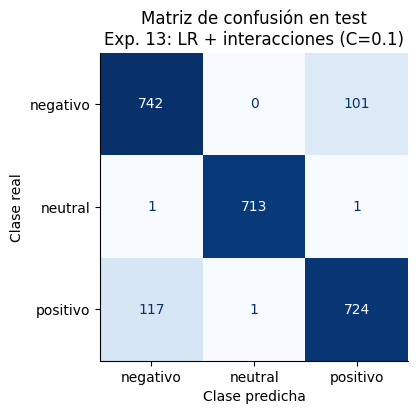

Negativo vs positivo en test: 0.870
  neg/pos evasiva    ( 285): 0.502
  neg/pos secundaria ( 101): 0.842
  neg/pos resto      (1299): 0.953


In [14]:
metricas_e13 = evaluar_en_test(modelo_e13, f"Exp. 13: {COMBINADOR}")
grupo_test = np.array([grupo_ruido(t) for t in X_test])
y_t, pred = y_test.to_numpy(), metricas_e13["pred"]
np_test = y_t != "neutral"
print(f"Negativo vs positivo en test: {(pred[np_test] == y_t[np_test]).mean():.3f}")
for nombre, m in [("evasiva", np_test & (grupo_test == "evasiva")), ("secundaria", np_test & (grupo_test == "secundaria")),
                  ("resto", np_test & (grupo_test == ""))]:
    print(f"  neg/pos {nombre:<10} ({m.sum():>4}): {(pred[m] == y_t[m]).mean():.3f}")

### 2.8 Prueba de robustez en test

In [15]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 13", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e13.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 12,Exp. 13,Exp. 8,Exp. 9
escenario,,,,
Original,0.8958,0.9079,0.9096,0.9029
Oraciones desordenadas,0.7317,0.7754,0.7621,0.7500
Última oración al inicio,0.5725,0.6546,0.6467,0.6021


### 2.9 Curva de aprendizaje

La forma más directa de saber si un modelo está limitado por sobreajuste o por falta de datos: entrenar con una
fracción creciente de cada fold de entrenamiento (25 %, 50 %, 75 %, 100 %) y medir la accuracy de entrenamiento y de
validación (5 folds). Se comparan la configuración del experimento 9 y la del experimento 13. Las accuracies se
calculan **sin las reseñas que terminan en evasiva** (las que ningún modelo puede predecir), para que la brecha mida
sobreajuste y no la memorización de etiquetas aleatorias.

- Si la curva de validación **sigue subiendo** al final y la de entrenamiento baja hacia ella: más datos ayudarían; el
  modelo no está sobrado de capacidad.
- Si la de validación ya está **plana** con una brecha grande: sobra capacidad (sobreajuste) y conviene regularizar.

Curva de aprendizaje en 12.8 min


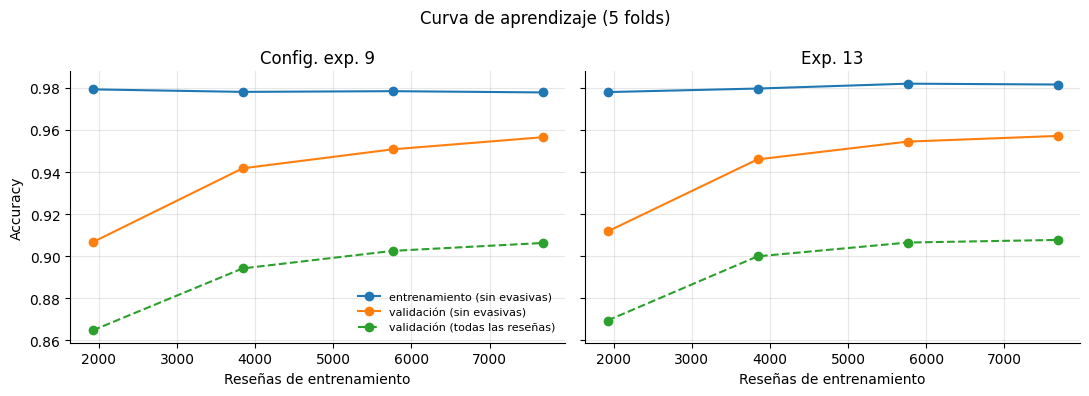

,modelo,reseñas de entrenamiento,train (sin evasivas),validación (sin evasivas),validación (todas)
0,Config. exp. 9,1920,0.9793,0.9066,0.8647
1,Config. exp. 9,3840,0.9781,0.9418,0.8942
2,Config. exp. 9,5760,0.9784,0.9508,0.9025
3,Config. exp. 9,7680,0.9779,0.9565,0.9062
4,Exp. 13,1920,0.9780,0.9117,0.8694
5,Exp. 13,3840,0.9797,0.9460,0.8999
6,Exp. 13,5760,0.9820,0.9545,0.9065
7,Exp. 13,7680,0.9816,0.9572,0.9077


In [16]:
FRACCIONES = [0.25, 0.5, 0.75, 1.0]
CONFIGS_CURVA = {
    "Config. exp. 9": dict(nivel2=svm_rbf()),
    "Exp. 13": dict(excluir=CONFIG.get("excluir", ()), donde=CONFIG.get("donde", ()), excluir_n2=FILTRO_N2,
                    nivel2=CANDIDATOS[COMBINADOR]()),
}


def _punto_curva(nombre, frac, idx_tr, idx_va):
    if frac < 1:
        idx_tr, _ = train_test_split(idx_tr, train_size=frac, stratify=y_np[idx_tr], random_state=SEED)
    m = DosNivelesE13(n_jobs=1, **CONFIGS_CURVA[nombre]).fit(X_train.iloc[idx_tr], y_np[idx_tr])
    a_tr = m.predict(X_train.iloc[idx_tr]) == y_np[idx_tr]
    a_va = m.predict(X_train.iloc[idx_va]) == y_np[idx_va]
    return {"modelo": nombre, "reseñas de entrenamiento": len(idx_tr),
            "train (sin evasivas)": a_tr[~RUIDO_A[idx_tr]].mean(), "validación (sin evasivas)": a_va[~RUIDO_A[idx_va]].mean(),
            "validación (todas)": a_va.mean()}


inicio = time.time()
puntos = Parallel(n_jobs=-1)(delayed(_punto_curva)(n, f, tr, va)
                             for n in CONFIGS_CURVA for f in FRACCIONES for tr, va in skf.split(X_train, y_train))
curva = pd.DataFrame(puntos).groupby(["modelo", "reseñas de entrenamiento"]).mean().reset_index()
print(f"Curva de aprendizaje en {(time.time() - inicio) / 60:.1f} min")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (nombre, d) in zip(axes, curva.groupby("modelo", sort=False)):
    ax.plot(d["reseñas de entrenamiento"], d["train (sin evasivas)"], marker="o", label="entrenamiento (sin evasivas)")
    ax.plot(d["reseñas de entrenamiento"], d["validación (sin evasivas)"], marker="o", label="validación (sin evasivas)")
    ax.plot(d["reseñas de entrenamiento"], d["validación (todas)"], marker="o", linestyle="--",
            label="validación (todas las reseñas)")
    ax.set_title(nombre)
    ax.set_xlabel("Reseñas de entrenamiento")
axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle("Curva de aprendizaje (5 folds)")
plt.tight_layout()
plt.show()
curva.round(4)

**Lectura**

- **La accuracy de entrenamiento (sin evasivas) es plana**, ≈ 0,98 con cualquier tamaño: el modelo siempre ajusta
  igual de bien sus datos de entrenamiento.
- **La de validación sigue subiendo** con más datos: 0,912 → 0,946 → 0,954 → 0,957 (exp. 13, sin evasivas). Entre
  5.760 y 7.680 reseñas todavía gana +0,3 puntos (+0,6 la configuración del exp. 9).
- Por eso **la brecha se cierra al aumentar los datos**: de ≈ 7 puntos con 1.920 reseñas a **≈ 2,4 con 7.680**. Es el
  patrón de un modelo cuyo límite es la cantidad de datos, **no** el de uno con capacidad sobrante que memoriza (en ese
  caso la validación se estancaría con una brecha grande).
- Consecuencia práctica: el modelo del envío, reentrenado con las 12.000 reseñas, debería rendir igual o un poco mejor
  que lo que estima la CV con 7.680.
- Las dos configuraciones tienen curvas casi idénticas; la del exp. 13 queda ligeramente por encima con 5.760 y 7.680
  reseñas.

### 2.10 Registro y envío

In [17]:
from types import SimpleNamespace

r_final = EVAL_COMB[COMBINADOR]
resultados.append({
    "experimento": 13,
    "descripcion": f"Dos niveles sin reseñas ruidosas ({VARIANTE.split(':')[0]}), {COMBINADOR}; CV 3 × 5",
    "acc_train": round(r_final["acc_train"].mean(), 4),
    "acc_cv": round(r_final["acc_cv"].mean(), 4),
    "std_cv": round(r_final["acc_cv"].std(ddof=0), 4),
    "acc_test": round(metricas_e13["acc_test"], 4),
    "f1_test": round(metricas_e13["f1_test"], 4),
    "envio": "submission_13.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91000
2,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN
3,9,"Dos niveles con corrección de tipeo, SVM RBF (C=1)",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
4,12,"Un nivel: exp. 11 sin reseñas ruidosas al entrenar, LinearSVC (C=0,5); CV 3 × 5",NaN,0.9188,0.9033,0.0070,NaN,0.8958,NaN,submission_12.csv,NaN
5,13,"Dos niveles sin reseñas ruidosas (V2), LR + interacciones (C=0.1); CV 3 × 5",NaN,0.9343,0.9089,0.0059,NaN,0.9079,0.9125,submission_13.csv,NaN


In [18]:
envio_e13 = generar_envio(SimpleNamespace(best_estimator_=modelo_e13), numero=13)

# Coincidencia con el envío del experimento 9 (cuántas predicciones de eval cambian)
envio_e9 = pd.read_csv("envios/submission_09.csv")
print(f"\nPredicciones iguales a submission_09.csv: {(envio_e9['answer'] == envio_e13['answer']).mean():.1%}")

Envío guardado en envios/submission_13.csv y modelo en modelos/modelo_13.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.0
neutral     27.6
positivo    36.4

Predicciones iguales a submission_09.csv: 94.6%


### 2.11 Análisis del experimento 13

**Resultados:** modelo de dos niveles del experimento 9 con **el nivel 1 entrenado sin las reseñas que terminan en
evasiva** (variante V2) y combinador **LR + interacciones de grado 2 (`C = 0,1`)**. CV 3 × 5 = **0,9087 ± 0,0059**;
test = **0,9083** (F1 macro 0,913).

| | Exp. 8 | Exp. 9 | Exp. 12 | **Exp. 13** |
|---|---|---|---|---|
| Modelo | 2 niveles, LR + interacciones | 2 niveles + corrector, SVM RBF | 1 nivel, sin ruidosas | 2 niveles + corrector, nivel 1 sin ruidosas, LR + interacciones |
| Accuracy CV | 0,9048 (5 folds) | 0,9065 (5 folds) · **0,9049 (3 × 5)** | 0,9033 (3 × 5) | **0,9087** (3 × 5) |
| Accuracy test | **0,9096** | 0,9029 | 0,8958 | 0,9083 |
| Test, oraciones desordenadas | 0,762 | 0,750 | 0,732 | **0,774** |
| Test, última oración al inicio | 0,647 | 0,602 | 0,573 | **0,654** |
| Kaggle público | — | **0,91555** | — | pendiente |

1. **La hipótesis 1 se confirma en dirección, no en significancia.** Con las mismas 15 particiones, el exp. 13 queda
   +0,38 puntos por encima de la configuración del experimento 9, pero p ≈ 0,16. En test, +0,54 puntos (≈ 13 reseñas,
   menos de un error estándar). Es el mejor valor de CV del proyecto, pero **sigue en la meseta de ≈ 0,905–0,909**.
2. **La mejora está donde se esperaba:** en las reseñas predecibles. En test, `negativo`/`positivo` "resto" se
   aciertan en un 95,4 %; las que terminan en evasiva, en un 50,2 % (azar, como cualquier modelo).
3. **El filtro debe ir en el nivel 1, no en el 2:** sacar las reseñas ruidosas del combinador empeora, porque necesita
   verlas para aprender que en ellas sus features no son fiables.
4. **Hipótesis 2 (sobreajuste) — respuesta:**
   - La brecha total del modelo de dos niveles es de ≈ 3 puntos; ≈ 1 punto es memorización de etiquetas aleatorias
     (reseñas evasivas: 59 % en entrenamiento frente a 50 % en validación), que no cuesta nada en datos nuevos.
   - En las reseñas predecibles, la brecha es de ≈ 2–3 puntos y **se cierra al aumentar los datos** (curva de
     aprendizaje). La validación sigue subiendo: el modelo está limitado por los datos, no por exceso de capacidad.
   - CV, test y Kaggle coinciden (0,905–0,916). **No hay evidencia de que los mejores modelos pierdan capacidad
     predictiva en datos nuevos de la misma distribución.**
   - Lo que sí los hace fallar es otro problema: dependen de que el veredicto esté al final de la reseña (robustez de
     0,65–0,77). Eso es **dependencia de la estructura** de este dataset, no memorización.
5. **Robustez:** el exp. 13 es el modelo de dos niveles más robusto (0,774 con las oraciones desordenadas y 0,654 con la
   última oración al inicio), como el exp. 8, que usa el mismo tipo de combinador lineal. Sigue dependiendo de la
   posición.
6. **En eval cambia el 5,4 % de las predicciones** respecto a `submission_09.csv` (≈ 160 reseñas). Parte de ellas son
   reseñas evasivas, que se deciden al azar, así que el score público puede moverse en cualquier dirección por ruido.

**Límites:**
- La mejora no es significativa: con este dataset, diferencias de 0,3 puntos están dentro del ruido de la CV.
- El filtro depende de la lista de frases evasivas construida a mano en el experimento 4 (con `X_train`).
- La variante y el combinador se eligieron con las mismas 15 particiones: la CV del ganador tiene un pequeño sesgo
  optimista. El test (que no se usó para decidir) es coherente con ella.

**Decisión:** el experimento 13 es el **mejor modelo según la validación interna** (CV y test), además de ser el más
robusto de los modelos de dos niveles y usar un combinador lineal fácil de sustentar. Se genera `submission_13.csv`.
Según el enunciado, el modelo que se entrega es el del **mejor score público**: si `submission_13` supera a 0,91555,
pasa a ser el modelo final; si no, se mantiene el experimento 9 y `submission_13` es la mejor opción como segundo envío
marcado para el ranking privado (decide mejor la CV que el leaderboard público).